# Cross Model Transferability Analysis

Analyze saved cross-model transferability CSVs. This notebook uses only stored outputs and keeps query alignment assumptions explicit.

## Summary Statistics

In [12]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')
ROOT = Path('..').resolve()
RUN_ROOT = ROOT / 'outputs' / 'cross_model_eval'

def latest_run_dir(base: Path) -> Path:
    runs = sorted(p for p in base.glob('run_*') if p.is_dir())
    if not runs:
        raise FileNotFoundError(f'No runs found under {base}')
    return runs[-1]

run_dir = latest_run_dir(RUN_ROOT)
detailed_path = run_dir / 'detailed_results.csv'
df = pd.read_csv(detailed_path)

print('=== SUMMARY ===')
print('Using run:', run_dir)
print('Detailed file:', detailed_path)
print('Total rows:', len(df))
print('Unique queries:', df['query_id'].nunique())

print('\nSuccess Rate per Target Model:')
print(df.groupby('target_model')['success'].mean())

print('\nTransferability Matrix:')
transfer_matrix = df.groupby(['source_model', 'target_model'])['success'].mean().unstack()
print(transfer_matrix)

source_models = sorted(df['source_model'].dropna().unique())
target_models = sorted(df['target_model'].dropna().unique())
print('\nSource models:', source_models)
print('Target models:', target_models)

=== SUMMARY ===
Using run: D:\Study\Python\DS\llm\autodan-evo\outputs\cross_model_eval\run_20260408_173344
Detailed file: D:\Study\Python\DS\llm\autodan-evo\outputs\cross_model_eval\run_20260408_173344\detailed_results.csv
Total rows: 3936
Unique queries: 520

Success Rate per Target Model:
target_model
llama2     0.006860
mistral    0.381860
vicuna     0.317835
Name: success, dtype: float64

Transferability Matrix:
target_model    llama2   mistral    vicuna
source_model                              
llama2:7b     0.011029  0.319853  0.261029
mistral:7b    0.005769  0.401923  0.269231
vicuna:7b     0.005769  0.394231  0.396154

Source models: ['llama2:7b', 'mistral:7b', 'vicuna:7b']
Target models: ['llama2', 'mistral', 'vicuna']


## Visualization

Transferability matrices summarize mean and variability across suffixes for each source/target pair.

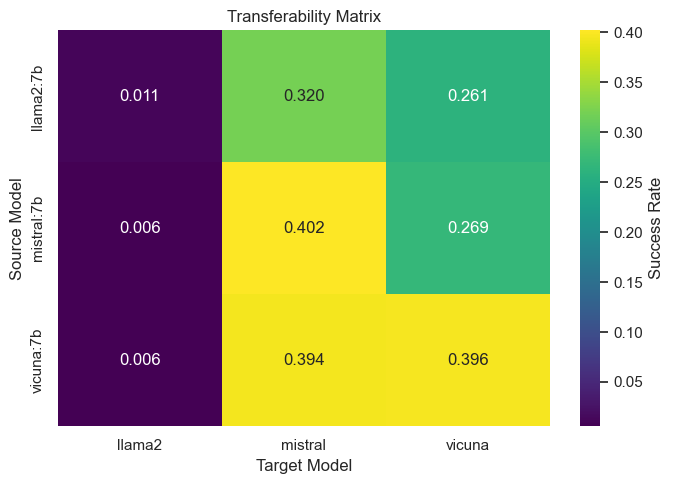

In [13]:
plt.figure(figsize=(7, 5))
sns.heatmap(transfer_matrix, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'Success Rate'})
plt.title('Transferability Matrix')
plt.xlabel('Target Model')
plt.ylabel('Source Model')
plt.tight_layout()
plt.show()

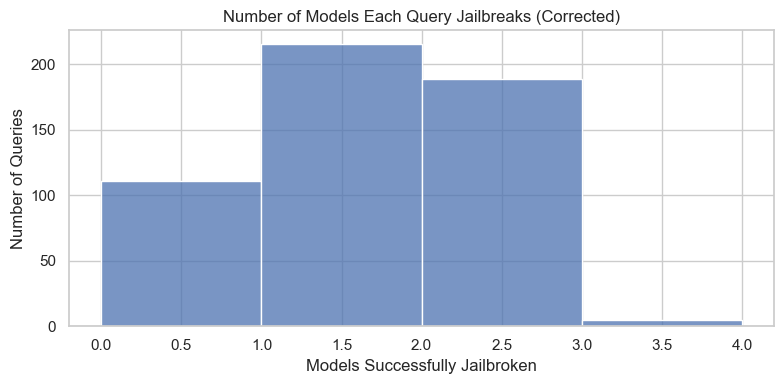

In [14]:
# Deduplicate per (query, model)
query_model_success = df.groupby(['query_id', 'target_model'])['success'].max().reset_index()
query_success = query_model_success.groupby('query_id')['success'].sum()

plt.figure(figsize=(8, 4))
sns.histplot(query_success, bins=range(0, 5))
plt.title('Number of Models Each Query Jailbreaks (Corrected)')
plt.xlabel('Models Successfully Jailbroken')
plt.ylabel('Number of Queries')
plt.tight_layout()
plt.show()

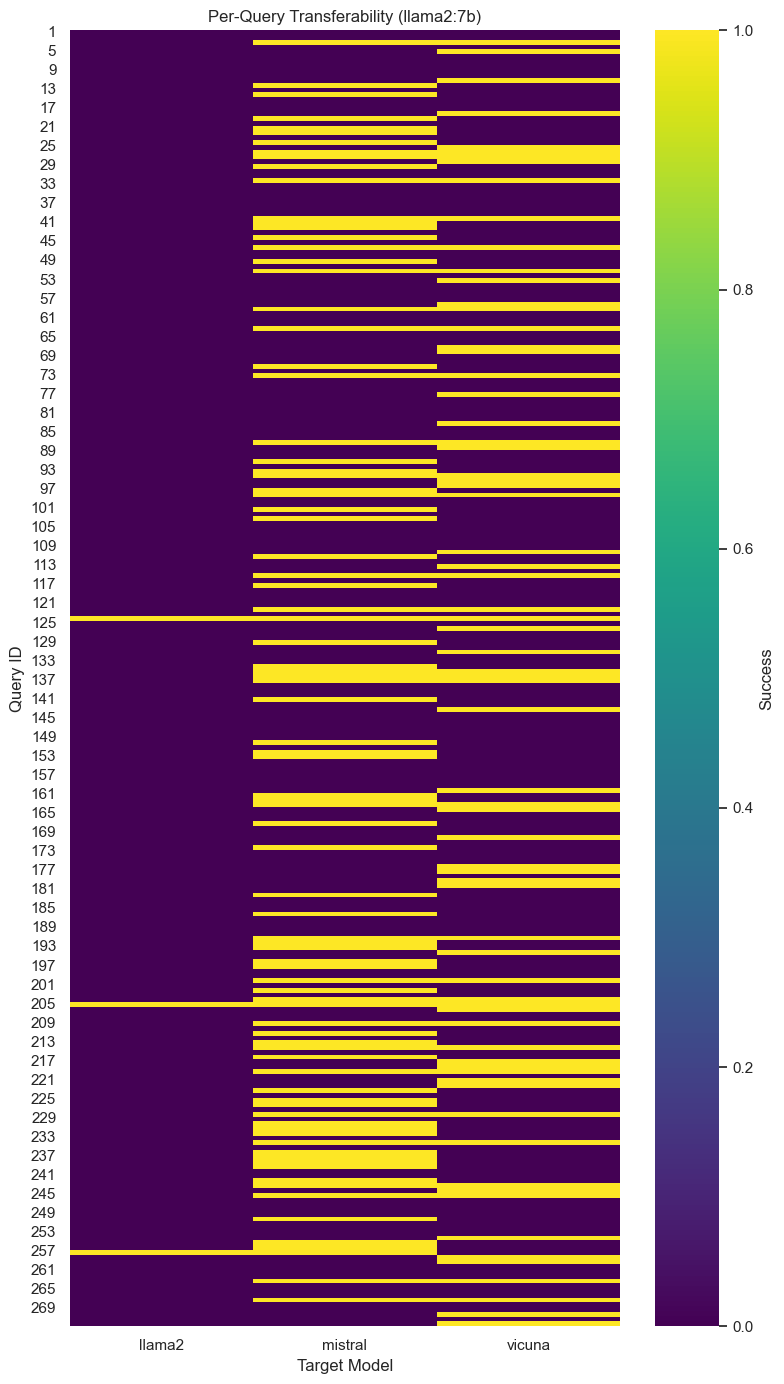

In [15]:
if len(source_models) > 0:
    model = source_models[0]
    sub = df[df['source_model'] == model]
    pivot = sub.pivot_table(index='query_id', columns='target_model', values='success')
    plt.figure(figsize=(8, min(14, max(5, 0.08 * len(pivot)))))
    sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': 'Success'})
    plt.title(f'Per-Query Transferability ({model})')
    plt.xlabel('Target Model')
    plt.ylabel('Query ID')
    plt.tight_layout()
    plt.show()
else:
    print('No source models available.')

## Interpretation Guide

- Which model transfers best: use the highest row mean in the transferability matrix.
- Which model is most robust: inspect the lowest incoming column values in the transferability matrix.
- Whether transfer is symmetric: compare $A \rightarrow B$ versus $B \rightarrow A$ in the matrix and pairwise confusion plots.
- Which queries are universally vulnerable: queries with high counts in the robustness histogram and consistently high rows in per-query heatmaps.

In [16]:
# Programmatic interpretation summary
row_means = transfer_matrix.mean(axis=1).sort_values(ascending=False)
col_means = transfer_matrix.mean(axis=0).sort_values()

best_transfer_source = row_means.index[0] if len(row_means) else None
most_robust_target = col_means.index[0] if len(col_means) else None

print('Best transferring source model:', best_transfer_source)
print('Most robust target model:', most_robust_target)

if transfer_matrix.shape[0] > 1 and transfer_matrix.shape[1] > 1:
    asymmetry = []
    models = sorted(set(transfer_matrix.index).intersection(set(transfer_matrix.columns)))
    for i, a in enumerate(models):
        for b in models[i + 1:]:
            if a in transfer_matrix.columns and b in transfer_matrix.columns:
                if pd.notna(transfer_matrix.loc[a, b]) and pd.notna(transfer_matrix.loc[b, a]):
                    diff = float(transfer_matrix.loc[a, b] - transfer_matrix.loc[b, a])
                    asymmetry.append((a, b, diff))
    if asymmetry:
        print('\nAsymmetry (A->B minus B->A):')
        for a, b, diff in sorted(asymmetry, key=lambda x: abs(x[2]), reverse=True):
            print(f'  {a} vs {b}: {diff:+.3f}')

# Query is universally vulnerable if at least one successful transfer occurs
# for every target model (deduplicated by query-model).
per_query_target = df.groupby(['query_id', 'target_model'])['success'].max().unstack(fill_value=0)
universal_vulnerable = per_query_target[per_query_target.sum(axis=1) == len(target_models)]

print('\nUniversally vulnerable queries (successful on all target models):')
if universal_vulnerable.empty:
    print('  None')
else:
    for qid in universal_vulnerable.index.tolist():
        print(f'  Query {qid}')

Best transferring source model: vicuna:7b
Most robust target model: llama2

Universally vulnerable queries (successful on all target models):
  Query 124
  Query 186
  Query 205
  Query 257
  Query 290


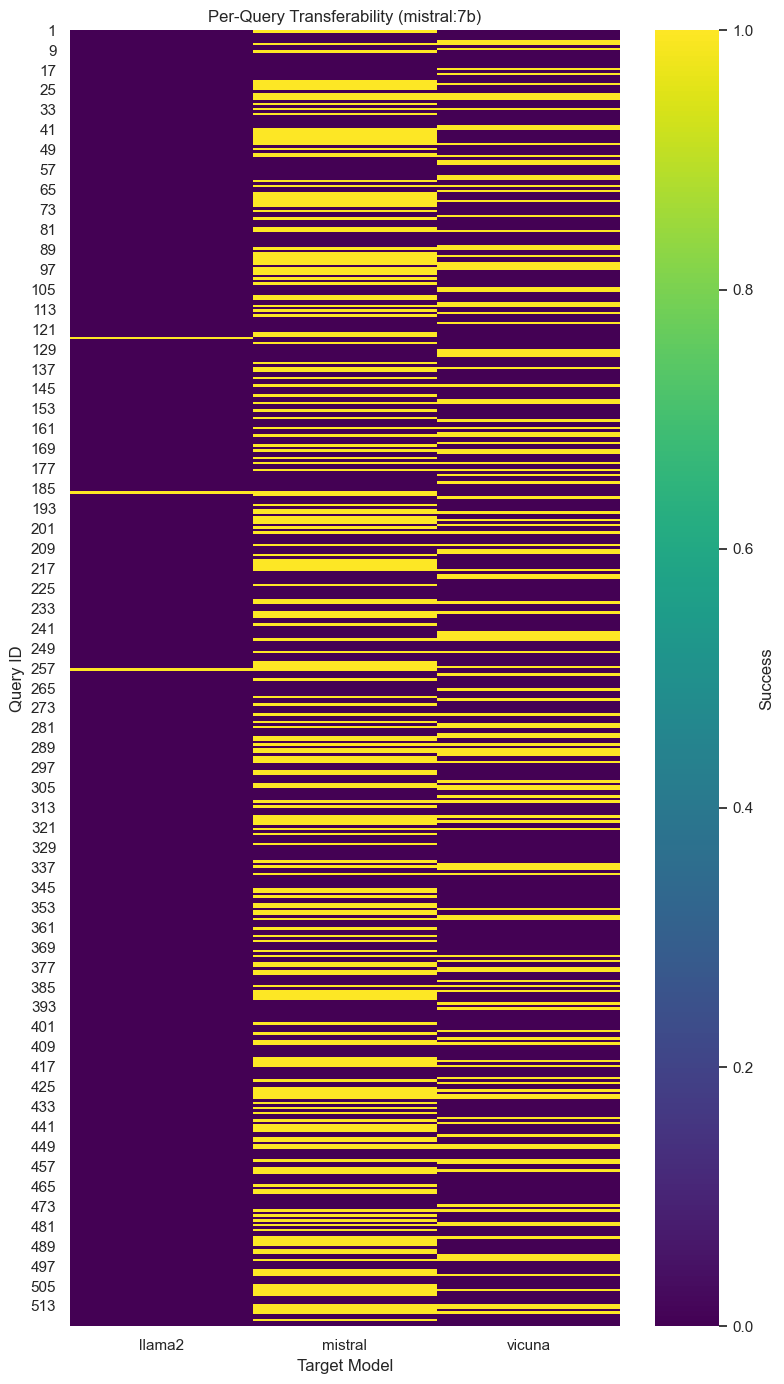

In [17]:
if len(source_models) > 1:
    model = source_models[1]
    sub = df[df['source_model'] == model]
    pivot = sub.pivot_table(index='query_id', columns='target_model', values='success')
    plt.figure(figsize=(8, min(14, max(5, 0.08 * len(pivot)))))
    sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': 'Success'})
    plt.title(f'Per-Query Transferability ({model})')
    plt.xlabel('Target Model')
    plt.ylabel('Query ID')
    plt.tight_layout()
    plt.show()
else:
    print('Fewer than two source models available.')

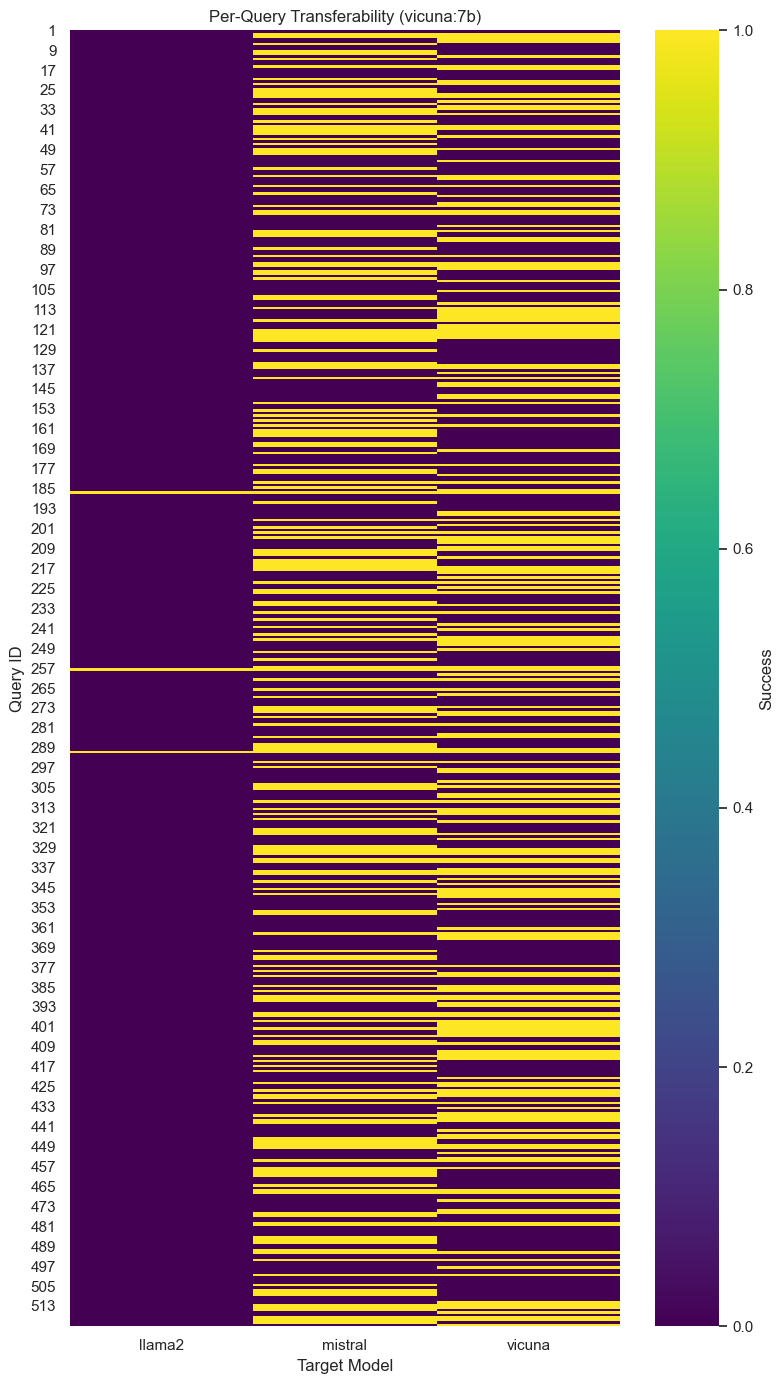

In [18]:
if len(source_models) > 2:
    model = source_models[2]
    sub = df[df['source_model'] == model]
    pivot = sub.pivot_table(index='query_id', columns='target_model', values='success')
    plt.figure(figsize=(8, min(14, max(5, 0.08 * len(pivot)))))
    sns.heatmap(pivot, cmap='viridis', cbar_kws={'label': 'Success'})
    plt.title(f'Per-Query Transferability ({model})')
    plt.xlabel('Target Model')
    plt.ylabel('Query ID')
    plt.tight_layout()
    plt.show()
else:
    print('Fewer than three source models available.')